In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
import json
import os
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from utils.img_utils import resize_long_edge
from utils.caption_utils import scene_generate_v2, reason_generate

from nuscenes.nuscenes import NuScenes
from data.nuscenes_data import NuscenesData
from pathlib import Path

import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import re

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load VLM (Qwen3-VL) model

In [2]:
model_id = "Qwen/Qwen3-VL-8B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Load data

In [3]:
# Load dataset
data_path = Path("/home/ximeng/Dataset/nuscenes_full_v1_0/")
nusc = NuScenes(version='v1.0-mini', dataroot=data_path)
is_train = 0 # 0: train, 1: val, 2: test
pre_frame = 4 # 2s
future_frame = 12 # 6s
dataset = NuscenesData(nusc, is_train, pre_frame, future_frame)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.288 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
target_index = 155
sample = dataset[target_index]
token = sample['token']
# Images and LiDAR
raw_images = sample['raw_images']
raw_lidar = sample['raw_lidar']
# Ego state
pre_waypoints = sample['pre_waypoints']
velocity = sample['velocity']
acceleration = sample['accel']
yaw_rate = sample['yaw_rate']
# High-level command
command = sample['command']
# Ground truth
future_waypoints = sample['future_waypoints']

In [5]:
# Images
print(f"Images shape: {raw_images.shape}")  # [5, 6, 3, 900, 1600]
# Ego state
print(f"pre_waypoints: {pre_waypoints}")
print(f"velocity: {velocity}, acceleration: {acceleration}, yaw_rate: {yaw_rate}")
# High-level command
print(f"command: {command}")

Images shape: torch.Size([5, 6, 3, 900, 1600])
pre_waypoints: tensor([[-5.1206,  1.2885, -0.3341],
        [-3.8192,  0.8343, -0.3238],
        [-2.5339,  0.4221, -0.2714],
        [-1.2533,  0.1023, -0.1620]])
velocity: tensor([2.5761, 2.6343, 2.5898, 2.5516, 2.6645]), acceleration: tensor([[ 0.5579, -0.2465],
        [-0.0957, -0.0937],
        [-0.2947,  0.3369],
        [-0.2797,  0.6610],
        [ 0.3139,  0.8594]]), yaw_rate: tensor([0.0017, 0.0586, 0.1555, 0.2500, 0.3700])
command: Turn Left


In [6]:
# Process images
current_images = raw_images[-1]  # [6, 3, H, W]
pil_images = []
new_order = [2, 3, 4, 5, 0, 1]
for i in new_order:
    img_np = current_images[i].permute(1, 2, 0).cpu().numpy() # H, W, 3
    img_pil = Image.fromarray(img_np)
    img_pil = resize_long_edge(img_pil, 512)
    pil_images.append(img_pil)

pil_past_images = []
past_images = raw_images[-3]
for i in new_order:
    img_np = past_images[i].permute(1, 2, 0).cpu().numpy() # H, W, 3
    img_pil = Image.fromarray(img_np)
    img_pil = resize_long_edge(img_pil, 1024)
    pil_past_images.append(img_pil)    
    
# Prepare waypoint prompt
pts = pre_waypoints.cpu().numpy().tolist()
wp_strings = [f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in pts]
wp_past = ", ".join(wp_strings)
# Prepare velocity, acceleration, yaw_rate
vel_val = round(velocity[-1].item(), 2)
acc_val = [round(float(a), 2) for a in acceleration[-1]] # [ax, ay]
yr_val = round(yaw_rate[-1].item(), 2)
high_level_command = None  # Placeholder for high-level command

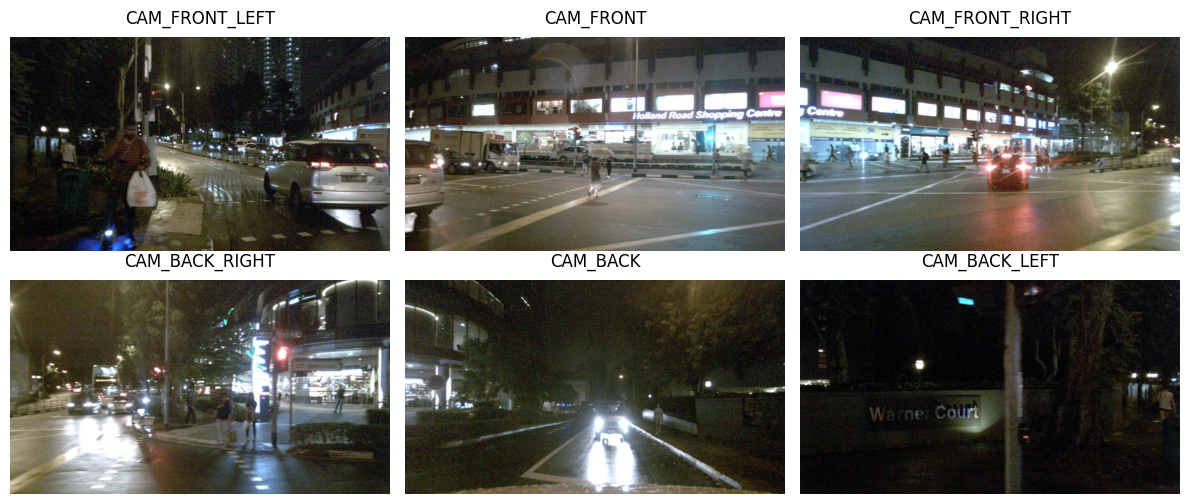

In [7]:
camera_names = ["CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT", "CAM_BACK", "CAM_BACK_LEFT"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < len(pil_past_images):
        ax.imshow(pil_past_images[i])
        ax.set_title(camera_names[i], fontsize=12, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.7)
plt.show()

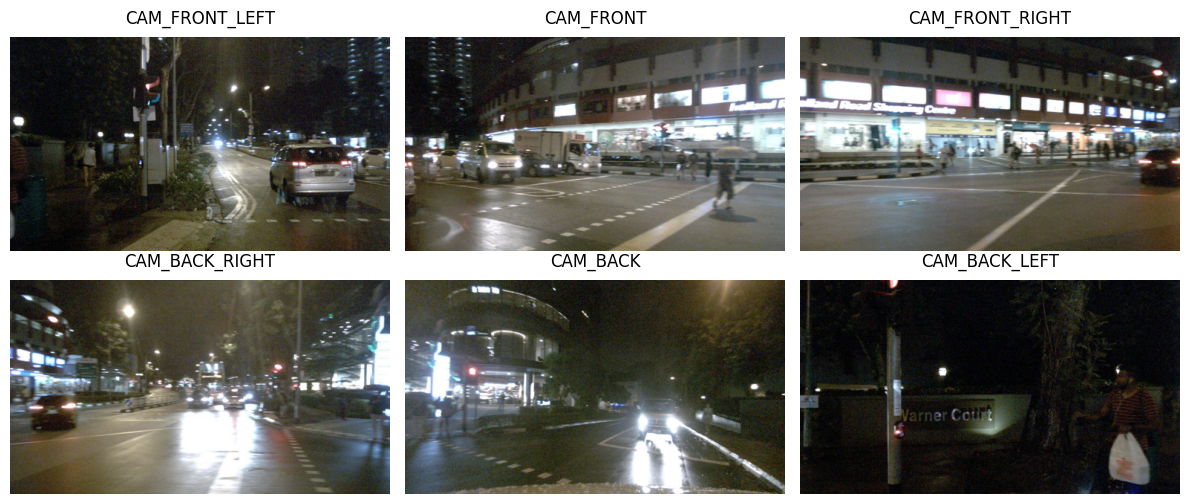

In [8]:
camera_names = ["CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT", "CAM_BACK", "CAM_BACK_LEFT"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < len(pil_images):
        ax.imshow(pil_images[i])
        ax.set_title(camera_names[i], fontsize=12, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.7)
plt.show()

In [9]:
print(wp_past)
print(vel_val, acc_val, yr_val)

(-5.12, 1.29), (-3.82, 0.83), (-2.53, 0.42), (-1.25, 0.10)
2.66 [0.31, 0.86] 0.37


# 

## Navigator (Large VLM)

In [10]:
# System and user prompts
system_prompt = (
    "You are an expert autonomous driving navigator. Your task is to analyze a 360-degree surround-view driving environment and provide concise, safety-oriented driving guidance.\n"
    "Guidelines:\n"
    "1. Coordinate System: The x-axis positive is forward, the y-axis positive is left.\n"
    "2. Attention Priority: Focus on 'Dynamic Hazards' (pedestrians, moving vehicles) and 'Traffic Regulators' (lights, signs, lane markings). Do not assume a red pedestrian signal implies vehicles must stop.\n"
    "3. Camera Emphasis: Focus primarily on information from the front cameras.\n"
    "4. Output Format: Start with a concise 'Perception' summary, followed by 'Action', and a brief 'Reasoning'.\n"
)
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {vel_val:.2f} m/s.\n"
    f"- Yaw Rate: {yr_val:.2f} rad/s.\n"
    f"- Acceleration (Longitudinal x, Lateral y): ({acc_val[0]:.2f}, {acc_val[1]:.2f}) m/s^2.\n"
    f"- Past Trajectory (2Hz): {wp_past} m.\n\n"
    f"- High-level Command: {command}\n"
)
user_prompt = (
    f"Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
    f"1:FRONT_LEFT, 2:FRONT, 3:FRONT_RIGHT, 4:BACK_RIGHT. 5:BACK, 6:BACK_LEFT, \n\n"
    f"{ego_status_prompt}"
    "Task: Analyze the current situation and provide the safest next action with reasons."
)
# Full prompt
content = [{"type": "image"} for _ in range(len(pil_images))]
content.append({"type": "text", "text": user_prompt})

In [11]:
print(system_prompt)
print(user_prompt)

You are an expert autonomous driving navigator. Your task is to analyze a 360-degree surround-view driving environment and provide concise, safety-oriented driving guidance.
Guidelines:
1. Coordinate System: The x-axis positive is forward, the y-axis positive is left.
2. Attention Priority: Focus on 'Dynamic Hazards' (pedestrians, moving vehicles) and 'Traffic Regulators' (lights, signs, lane markings). Do not assume a red pedestrian signal implies vehicles must stop.
3. Camera Emphasis: Focus primarily on information from the front cameras.
4. Output Format: Start with a concise 'Perception' summary, followed by 'Action', and a brief 'Reasoning'.

Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.
1:FRONT_LEFT, 2:FRONT, 3:FRONT_RIGHT, 4:BACK_RIGHT. 5:BACK, 6:BACK_LEFT, 

Current Dynamics:
- Velocity: 2.66 m/s.
- Yaw Rate: 0.37 rad/s.
- Acceleration (Longitudinal x, Lateral y): (0.31, 0.86) m/s^2.
- Past Trajectory (2Hz): (-5.12, 1.29), (-3.82, 0.83), (-2.53, 0.42), (-1.25, 

# Generate Reason

In [12]:
messgae, reason = scene_generate_v2(
    full_prompt=content,
    system=system_prompt,
    images=pil_images,
    processor=processor,
    model=model,
    do_sample=True
)
print(reason)

Perception: The ego-vehicle is approaching an intersection at night with moderate traffic and pedestrians. The front camera shows a red traffic light ahead, indicating the vehicle must stop. Pedestrians are visible crossing the street, and other vehicles are present in adjacent lanes. The vehicle is currently moving at 2.66 m/s with a yaw rate of 0.37 rad/s, suggesting a slight turn is underway.

Action: Stop the vehicle at the stop line. Do not proceed until the traffic light turns green and the pedestrian crossing is clear.

Reasoning: The red traffic light is a regulatory command that must be obeyed regardless of the vehicle’s current velocity or trajectory. Proceeding while the light is red poses a high risk of collision with pedestrians or other vehicles. The yaw rate and past trajectory suggest the vehicle may be turning, but the primary safety concern is compliance with the traffic signal and ensuring pedestrian safety.


In [13]:
reason_gemini = (
    "Perception: Critical Dynamics: The ego-vehicle is executing a low-speed left turn (Yaw Rate: 0.37 rad/s) at a wet, nighttime urban intersection.Hazards:CAM_FRONT: A pedestrian is actively crossing the road from right to left, directly in the ego-vehicle's intended path (crosswalk).CAM_FRONT: A white truck/van is navigating the intersection ahead, potentially obstructing the exit lane.CAM_BACK: A vehicle is following with headlights on; sudden braking could pose a rear-end risk.Environment: Road surface is wet, increasing stopping distances and glare."
    "Action: DECELERATE / YIELD Transition from positive acceleration ($0.31 m/s^2$) to braking. Prepare to bring the vehicle to a complete stop if the pedestrian does not clear the lane immediately. Maintain the current steering curvature to complete the turn only once the crosswalk is clear."
    "Reasoning: Despite the low current velocity ($2.66 m/s$), the vehicle is currently accelerating ($+0.31 m/s^2$ longitudinal) directly toward a vulnerable road user (VRU) in the crosswalk. Prioritizing the pedestrian is the absolute safety requirement. The wet road conditions necessitate earlier braking intervention to prevent skidding. The following vehicle in CAM_BACK requires the stop to be smooth, but does not override the need to yield to the pedestrian ahead."
)

# Driver (Small VLA)

In [14]:
driver_system_prompt = (
    "You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.\n"
    "Rules:\n"
    "1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.\n"
    "2. Trajectory Timing: Output exactly 12 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).\n"
    "3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.\n"
    "4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.\n"
    "5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12)."
)
driver_user_prompt = (
    "Predict the next 12 waypoints."
)
full_driver_prompt = (
    f"Navigator's Analysis and Instructions:\n{reason}\n\n"
    f"{ego_status_prompt}\n"
    f"{driver_user_prompt}"
)

# Generate Action

In [15]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "checkpoints/qwen3-1.7b-dllm-sft-0201"
ORIGINAL_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(ORIGINAL_MODEL_ID, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048, padding_idx=151643)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (

In [21]:
messgae, output = reason_generate(
    user=full_driver_prompt,
    system=driver_system_prompt,
    # images=pil_images,
    processor=processor,
    model=model,
    do_sample=True,
    max_new_tokens=16
)
print(output)

<think>

</think>

Future Waypoints: (1.60, 0.42), (2.87, 0.90), (4.05, 1.60), (5.16, 2.40), (6.25, 3.30), (7.35, 4.30), (8.45, 5.40), (9.56, 6.60), (10.67, 8.00), (11.78, 9.50), (12.89, 11.20), (13.99, 13.10), (14.99, 15.20), (15.99, 17.50), (16.99, 19.90), (17.99, 22.50), (18.99, 25.30), (19.99, 28.30), (20.99, 31.50), (21.99, 34.90), (22.99, 38.50), (23.99, 42.30), (24.99, 46.30), (25.99, 50.50), (26.99, 54.90), (27.99, 59.50), (28.99, 64.30), (29.99, 69.30), (30.99, 74.50), (31.99, 79.90), (32.99, 85.50), (33.99, 91.30), (34.99, 97.30), (35.99, 103.50), (36.99, 109.90), (37.99, 116.50), (38.99, 123.30),


In [22]:
def parse_waypoints(vlm_str):
    pattern = r"\((-?\d+\.?\d*),\s*(-?\d+\.?\d*)\)"
    matches = re.findall(pattern, vlm_str)
    
    if matches:
        waypoints = np.array(matches, dtype=float)
        return waypoints
    else:
        print("Warning: No waypoints found in VLM output!")
        return np.array([])

In [23]:
def plot_comparison(gt_pts, vlm_str):
    pred_pts = parse_waypoints(vlm_str)
    
    plt.figure(figsize=(10, 6))
    
    # Ground truth waypoints (Blue)
    plt.plot(gt_pts[:, 0], gt_pts[:, 1], 'bo-', label='Ground Truth', alpha=0.6)
    
    # Predicted waypoints (Red)
    if len(pred_pts) > 0:
        plt.plot(pred_pts[:, 0], pred_pts[:, 1], 'ro--', label='VLM Prediction')
    
    # Origin
    plt.plot(0, 0, 'gX', markersize=10, label='Current Pos')
    
    plt.xlabel('Forward Distance (x) [m]')
    plt.ylabel('Lateral Distance (y) [m]')
    plt.title('Trajectory Comparison: VLM vs Ground Truth')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Results

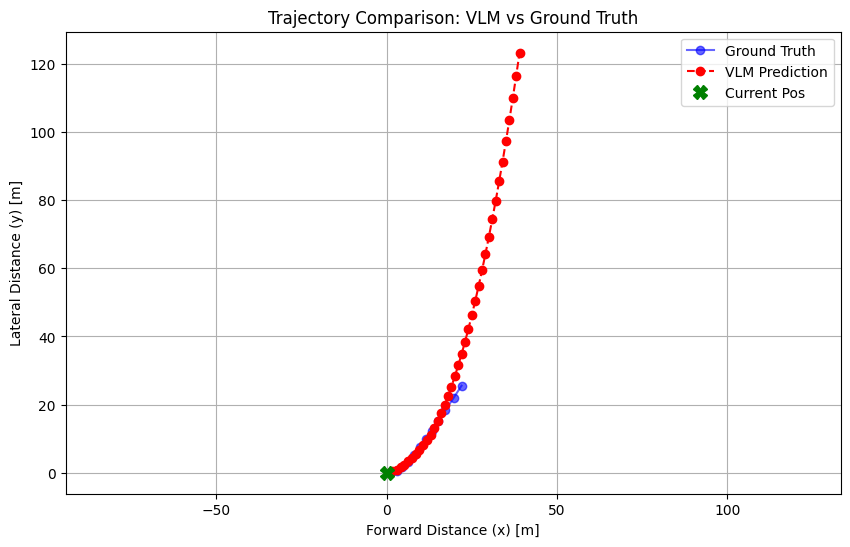

In [24]:
plot_comparison(future_waypoints, output)

# Record Data

In [20]:
wp_future = ", ".join([f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in future_waypoints])

data_record = {
    "token": token,
    "wp_past": wp_past,
    "vel_val": vel_val,
    "acc_val": acc_val,
    "yr_val": yr_val,
    "reason": reason,
    "wp_future": wp_future
}

with open('output.jsonl', 'a', encoding='utf-8') as f:
    json.dump(data_record, f, ensure_ascii=False)
    f.write('\n')

print("Record saved to output.jsonl")

Record saved to output.jsonl
